You are using a model of type chinese_clip to instantiate a model of type clip. This is not supported for all configurations of models and can yield errors.
Some weights of CLIPModel were not initialized from the model checkpoint at ../model/chinese-clip-vit-base-patch16 and are newly initialized: ['text_model.embeddings.position_embedding.weight', 'text_model.embeddings.token_embedding.weight', 'text_model.encoder.layers.0.layer_norm1.bias', 'text_model.encoder.layers.0.layer_norm1.weight', 'text_model.encoder.layers.0.layer_norm2.bias', 'text_model.encoder.layers.0.layer_norm2.weight', 'text_model.encoder.layers.0.mlp.fc1.bias', 'text_model.encoder.layers.0.mlp.fc1.weight', 'text_model.encoder.layers.0.mlp.fc2.bias', 'text_model.encoder.layers.0.mlp.fc2.weight', 'text_model.encoder.layers.0.self_attn.k_proj.bias', 'text_model.encoder.layers.0.self_attn.k_proj.weight', 'text_model.encoder.layers.0.self_attn.out_proj.bias', 'text_model.encoder.layers.0.self_attn.out_proj.weight', 'text

预测概率: tensor([[0.3307, 0.3350, 0.3342]])
预测结果: a photo of a cat
置信度: 0.34


D:\Software\Miniconda\envs\py312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Software\Miniconda\envs\py312\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


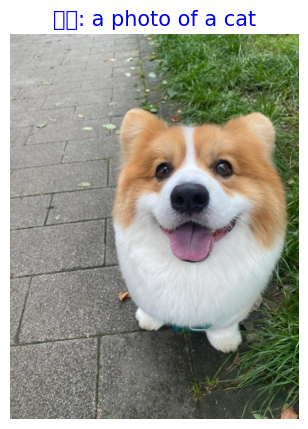

In [3]:
# 1. 确保导入部分包含 AutoProcessor
from transformers import AutoProcessor, CLIPModel
import torch
from PIL import Image

# 2. 加载模型和处理器（确保这里用的是 AutoProcessor 或者分开写）
model_id = "../model/chinese-clip-vit-base-patch16" # 或者你本地模型的路径
model = CLIPModel.from_pretrained(model_id)
processor = AutoProcessor.from_pretrained(model_id)

# --- 你的作业代码开始 ---

# 1. 加载图片
image_path = "gougou.jpg" # 确保图片在当前目录，或者写绝对路径
image = Image.open(image_path)

# 2. 定义候选类别
candidate_labels = ["a photo of a dog", "a photo of a cat", "a photo of a car"]

# 3. 图片预处理（单独处理）
# 注意：这里只用 processor 处理 image 参数
inputs_image = processor(images=image, return_tensors="pt")

# 4. 获取图片特征
with torch.no_grad():
    image_features = model.get_image_features(**inputs_image)
    # 归一化
    image_features = image_features / image_features.norm(p=2, dim=-1, keepdim=True)

# 5. 文本预处理（单独处理）
# 注意：这里只用 processor 处理 text 参数
inputs_text = processor(text=candidate_labels, return_tensors="pt", padding=True)

# 6. 获取文本特征
# 1. 先检查并移除模型不需要的 'token_type_ids'
if 'token_type_ids' in inputs_text:
    inputs_text.pop('token_type_ids')

# 2. 再传入模型
with torch.no_grad():
    text_features = model.get_text_features(**inputs_text)
    # 归一化
    text_features = text_features / text_features.norm(p=2, dim=-1, keepdim=True)

# 7. 计算相似度
logits_per_image = image_features @ text_features.t() # 矩阵乘法
probs = logits_per_image.softmax(dim=-1) # 转为概率

print("预测概率:", probs)


# --- 接在你计算 probs 的代码后面 ---

# 1. 打印预测结果
print(f"预测结果: {candidate_labels[probs.argmax()]}")
print(f"置信度: {probs.max():.2f}")

# 2. 显示图片
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.imshow(image)  # 显示你加载的那张图片
plt.title(f"预测: {candidate_labels[probs.argmax()]}", fontsize=15, color='blue')
plt.axis('off')    # 关掉坐标轴
plt.show()